# Lesson 05.1: Hoeffding Inequality Interactive Study

**Course**: MSML610: Advanced Machine Learning

**Instructor**: Dr. GP Saggese

**Purpose**: Interactive exploration of the Hoeffding inequality through
Bernoulli binomial sampling experiments.

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import seaborn as sns

import utils_Lesson05_Learning_Theory as utils

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [4]:
import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

vim support installed: restart the notebook, if needed


Python 3.12.3
Linux e5e5da9c612b 6.10.14-linuxkit #1 SMP Tue Apr 15 16:00:54 UTC 2025 aarch64 aarch64 aarch64 GNU/Linux


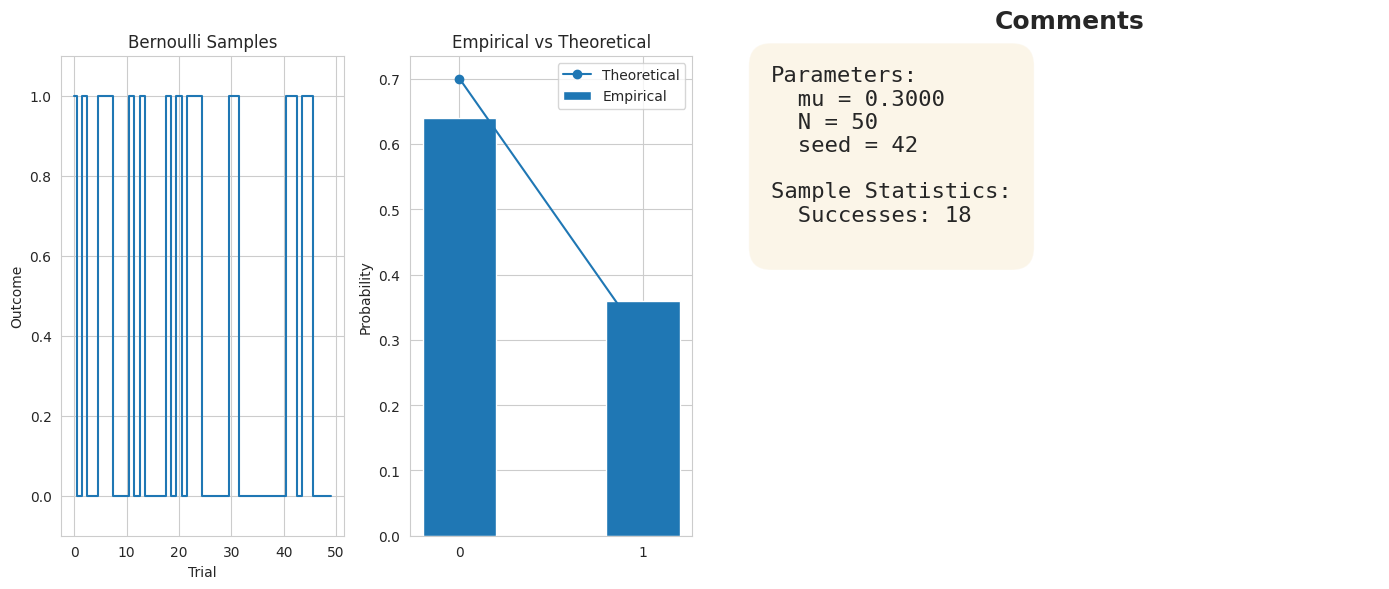

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data generation
# -----------------------------
mu = 0.3
N = 50
seed = 42

rng = np.random.default_rng(seed)
samples = rng.binomial(1, mu, size=N)

n_successes = samples.sum()
n_failures = N - n_successes
empirical_prob = n_successes / N

# -----------------------------
# Figure & layout
# -----------------------------
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 2.2])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# -----------------------------
# Plot 1: Sample path
# -----------------------------
ax1.step(range(N), samples, where="mid")
ax1.set_title("Bernoulli Samples")
ax1.set_xlabel("Trial")
ax1.set_ylabel("Outcome")
ax1.set_ylim(-0.1, 1.1)

# -----------------------------
# Plot 2: Empirical vs theoretical
# -----------------------------
ax2.bar([0, 1], [n_failures / N, n_successes / N], width=0.4, label="Empirical")
ax2.plot([0, 1], [1 - mu, mu], "o-", label="Theoretical")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["0", "1"])
ax2.set_title("Empirical vs Theoretical")
ax2.set_ylabel("Probability")
ax2.legend()

# -----------------------------
# Plot 3: Comments and explanation
# -----------------------------
ax3.axis("off")
ax3.set_title("Comments", fontsize=18, fontweight="bold", pad=20)

text_content = (
    f"Parameters:\n"
    f"  mu = {mu:.4f}\n"
    f"    (true probability)\n"
    f"  N = {N}\n"
    f"    (number of samples)\n"
    f"  seed = {seed}\n\n"
    # f"Sample Statistics:\n"
    # f"  Successes (1): {n_successes}\n"
    # f"  Failures (0): {n_failures}\n"
    # f"  Empirical prob: {empirical_prob:.4f}\n\n"
    # f"Interpretation:\n"
    # f"  Each sample is an independent Bernoulli trial "
    # f"with success probability mu.\n\n"
    # f"  The left plot shows samples as they occur over time.\n\n"
    # f"  The center plot compares the empirical PDF (bars) "
    # f"with the theoretical probabilities (blue line)."
)

def add_fitted_text_box(
    ax,
    text,
    box_xy=(0.02, 0.98),
    box_width=0.96,
    box_height=0.96,
    max_fontsize=16,
    min_fontsize=8,
):
    """
    Add a text box that fills a given axes region and
    automatically scales font size to fit vertically.
    """
    ax.figure.canvas.draw()  # ensure renderer exists
    renderer = ax.figure.canvas.get_renderer()

    for fontsize in range(max_fontsize, min_fontsize - 1, -1):
        txt = ax.text(
            box_xy[0],
            box_xy[1],
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            wrap=True,
            fontsize=fontsize,
            family="monospace",
            bbox=dict(
                boxstyle="round,pad=1.0",
                facecolor="wheat",
                alpha=0.3,
            ),
        )

        bbox = txt.get_window_extent(renderer=renderer)
        ax_bbox = ax.get_window_extent(renderer=renderer)

        if bbox.height <= box_height * ax_bbox.height:
            return txt

        txt.remove()

    # fallback (smallest font)
    ax.text(
        box_xy[0],
        box_xy[1],
        text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        wrap=True,
        fontsize=min_fontsize,
        family="monospace",
        bbox=dict(
            boxstyle="round,pad=1.0",
            facecolor="wheat",
            alpha=0.3,
        ),
    )

text_content = (
    f"Parameters:\n"
    f"  mu = {mu:.4f}\n"
    f"  N = {N}\n"
    f"  seed = {seed}\n\n"
    f"Sample Statistics:\n"
    f"  Successes: {n_successes}\n"
    # f"  Failures: {n_failures}\n"
    # f"  Empirical prob: {empirical_prob:.4f}\n\n"
    # f"Interpretation:\n"
    # f"  Each sample is an independent Bernoulli trial "
    # f"with success probability mu.\n\n"
    # f"  The left plot shows the sample path.\n"
    # f"  The center plot compares empirical and theoretical probabilities."
)

add_fitted_text_box(ax3, text_content)

# -----------------------------
# Final spacing (Jupyter-safe)
# -----------------------------
plt.tight_layout()
plt.show()

# Building Intuition about Hoeffding Inequality

We will build intuition about the Hoeffding Inequality progressively through
multiple cells, each adding more understanding about how sample means relate
to the true probability.

## Basic Bernoulli Sampling Code

Start with a simple code example showing how to create Bernoulli samples and
compute basic statistics.

In [28]:
# Demonstrate basic Bernoulli sampling.
utils.sample_bernoulli1()
# This shows the code for generating samples and computing the empirical mean.

Parameters:
  True probability (mu): 0.6
  Number of samples (N): 10
  Random seed: 42

Generated samples:
  [1 0 0 1 1 1 1 0 0 0]

Statistics:
  Number of successes (1s): 5
  Number of failures (0s): 5
  Empirical mean (nu): 0.5000
  True mean (mu): 0.6000
  Error |nu - mu|: 0.1000


## Samples Over Time and Empirical PDF

Visualize the N samples from a Bernoulli distribution both as a sequence over
time and as an empirical probability distribution function (PDF).

**Parameters**:
- `mu`: True probability of success (between 0 and 1)
- `N`: Number of samples to draw
- `seed`: Random seed for reproducibility

In [29]:
# Display N samples over time and their empirical PDF.
utils.sample_bernoulli2()

## PDF, Empirical Mean, and Statistics

Examine the probability distribution of N samples, compute the empirical mean
nu, and compare with the theoretical mean and variance of the Bernoulli
distribution.

**Key concepts**:
- Empirical mean nu = average of the samples
- Theoretical mean = mu
- Theoretical variance = mu * (1 - mu)
- Change the seed to generate new realizations

In [25]:
# Display PDF, empirical mean nu, and compare with theoretical statistics.
utils.sample_bernoulli3()
# Changing the seed generates new realizations with different empirical values.

## Distribution of Empirical Mean

Examine what happens when we repeatedly sample N points many times. Each
trial produces an empirical mean nu. This cell shows the distribution of nu
over many trials and compares it with the expected distribution predicted by
the Law of Large Numbers and Central Limit Theorem.

**Key concepts**:
- By the Law of Large Numbers, nu converges to mu as N increases
- By the Central Limit Theorem, nu is approximately normally distributed:
  nu ~ N(mu, sqrt(mu * (1-mu) / N))

In [27]:
# Display the distribution of empirical mean nu from repeated sampling.
utils.sample_bernoulli4()
# As N increases, the distribution becomes more concentrated around mu.